# 01 — Data Exploration and Understanding

**Retail Sales Analysis for Inventory Management — Course 307498, University of Petra**

Covers **Section 6 of the report — Data Description and Understanding**.

> **The problem.** Retailers order product-by-product, as though demand for each item were
> independent — but customers buy in baskets, and stock cover is applied uniformly across a
> catalogue whose items differ enormously in volume and volatility.

This notebook establishes whether the data can actually answer that. Four questions have to be
answered *before* any analysis is designed:

1. Are there enough **multi-item baskets** for association mining to be possible?
2. Is revenue **concentrated** enough for ABC classification to mean anything?
3. Is there enough **history per SKU** to forecast?
4. Are there enough **absence episodes** to test the pull-through claim?

Nothing is modified here. Every cleaning decision is deferred to `02_cleaning.ipynb`.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW  = ROOT / "data" / "raw" / "uci"
IMG  = ROOT / "images"; IMG.mkdir(exist_ok=True)

print("Project:", ROOT.name)

Project: retail-inventory-bi


## 1. The source file — and the first surprise

The file has **two sheets**, one per trading year. They must be combined, and the combination
is where the first data-quality problem appears.

In [3]:
src = RAW / "online_retail_II.xlsx"
sheets = pd.ExcelFile(src).sheet_names
print("sheets:", sheets)

parts = []
for s in sheets:
    p = pd.read_excel(src, sheet_name=s)
    p["source_sheet"] = s
    print(f"  {s:<20} {len(p):>9,} rows")
    parts.append(p)

raw = pd.concat(parts, ignore_index=True)
raw.columns = [c.strip().replace(" ", "_") for c in raw.columns]
print(f"\ncombined: {len(raw):,} rows x {raw.shape[1]} columns")
print(f"columns : {list(raw.columns)}")
raw.head(4)

sheets: ['Year 2009-2010', 'Year 2010-2011']
  Year 2009-2010         525,461 rows
  Year 2010-2011         541,910 rows

combined: 1,067,371 rows x 9 columns
columns : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country', 'source_sheet']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,source_sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010


## 2. The duplicate problem — two different things that look identical

A naive `duplicated()` check flags tens of thousands of rows. But they are **not all the same
kind of duplicate**, and treating them alike would be a mistake in one direction or the other.

rows flagged as duplicated: 67,246  (6.3%)


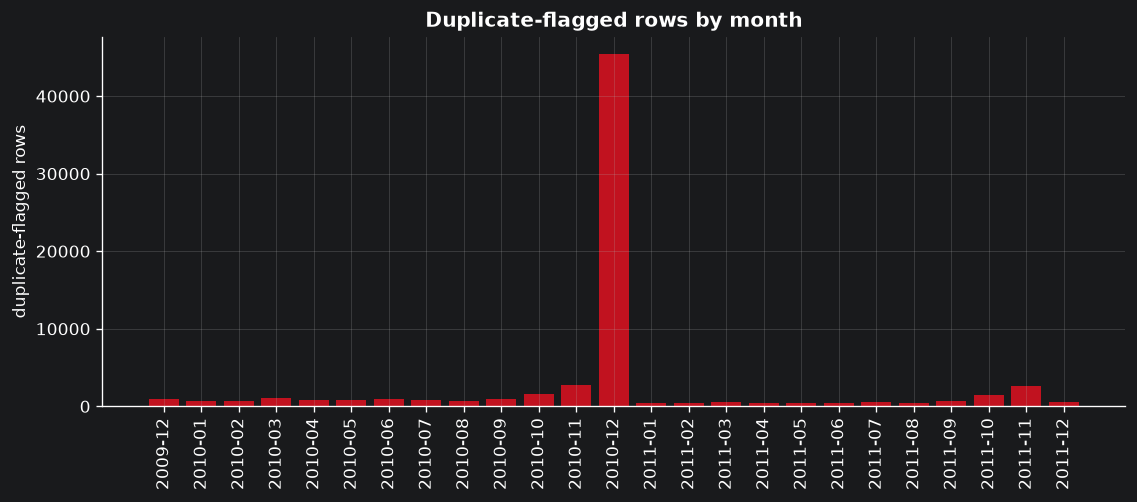

InvoiceDate
2010-12    45381
2010-11     2747
2011-11     2643
2010-10     1636
Freq: M


In [4]:
KEY = ["Invoice", "StockCode", "Quantity", "InvoiceDate", "Price"]

flagged = raw.duplicated(subset=KEY, keep=False)
print(f"rows flagged as duplicated: {flagged.sum():,}  ({100*flagged.mean():.1f}%)")

by_month = (raw[flagged]
            .groupby(pd.to_datetime(raw.loc[flagged, "InvoiceDate"]).dt.to_period("M"))
            .size())
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(by_month.index.astype(str), by_month.values, color="#C1121F")
ax.set_ylabel("duplicate-flagged rows"); ax.tick_params(axis="x", rotation=90)
ax.set_title("Duplicate-flagged rows by month", fontweight="bold")
plt.show()

print(by_month.sort_values(ascending=False).head(4).to_string())

### One month accounts for almost everything

**December 2010 carries ~45,000 flagged rows; every other month carries 400–2,700.**

The reason is visible in the sheet names: *Year 2009-2010* and *Year 2010-2011* both contain
December 2010. Those rows are **the same transaction published twice** — an artefact of how
the file was assembled, not a problem in the retailer's records.

The duplicates in the other months are a different thing entirely: identical lines *within* one
sheet. Entering the same product twice on one order is ordinary retail behaviour, and since
`InvoiceDate` is recorded per invoice, both lines share a timestamp by construction.

**Two kinds, two decisions** — made explicitly in notebook 02:

| Kind | Diagnosis | Decision |
|---|---|---|
| Cross-sheet (Dec 2010) | same transaction published twice | remove |
| Within-sheet | genuine repeated order lines | **keep** — removing them would delete real demand |

In [5]:
sheets_per_key = raw.groupby(KEY, dropna=False)["source_sheet"].transform("nunique")
cross = (sheets_per_key > 1) & raw.duplicated(subset=KEY, keep="first")
within = raw.duplicated(subset=KEY, keep=False).sum() - (sheets_per_key > 1).sum()

print(f"cross-sheet duplicates (to remove) : {cross.sum():,}")
print(f"within-sheet duplicates (to keep)  : approx {within:,}")
print(f"\n^ the difference between these two numbers is a decision, not a calculation.")

cross-sheet duplicates (to remove) : 22,844
within-sheet duplicates (to keep)  : approx 22,200

^ the difference between these two numbers is a decision, not a calculation.


## 3. The data dictionary

Eight fields. What matters is not what each contains, but what each makes *possible*.

In [6]:
dd = pd.DataFrame([
    ("Invoice",     "Transaction number. Leading 'C' = cancellation",
     "BASKET STRUCTURE — multiple SKUs share an invoice, so co-purchase can be mined"),
    ("StockCode",   "Product code (SKU)",
     "The unit of inventory decision. ABC/XYZ and reorder points are all per-SKU"),
    ("Description", "Product name",
     "Human-readable labels for the dashboard and for interpreting association rules"),
    ("Quantity",    "Units on the line. Can be negative (returns)",
     "DEMAND — the quantity being forecast"),
    ("InvoiceDate", "Date and time",
     "TIME — seasonality, weekly demand series, and the absence experiment"),
    ("Price",       "Unit price in GBP",
     "VALUE — turns units into revenue, which is what ABC classifies on"),
    ("Customer_ID", "Customer number (missing on ~23% of rows)",
     "Not required: this project works at invoice and SKU level, not customer level"),
    ("Country",     "Customer country",
     "Segmentation; ~92% United Kingdom"),
], columns=["field", "contents", "what it makes possible"])
dd

,field,contents,what it makes possible
0,Invoice,Transaction number. Leading 'C' = cancellation,BASKET STRUCTURE — multiple SKUs share an invo...
1,StockCode,Product code (SKU),The unit of inventory decision. ABC/XYZ and re...
2,Description,Product name,Human-readable labels for the dashboard and fo...
3,Quantity,Units on the line. Can be negative (returns),DEMAND — the quantity being forecast
4,InvoiceDate,Date and time,"TIME — seasonality, weekly demand series, and ..."
5,Price,Unit price in GBP,"VALUE — turns units into revenue, which is wha..."
6,Customer_ID,Customer number (missing on ~23% of rows),Not required: this project works at invoice an...
7,Country,Customer country,Segmentation; ~92% United Kingdom


## 4. Cancellations and returns

A cancellation is not demand — it is demand being reversed. It cannot sit in the sales table.
But it is real information about return behaviour, so it is separated rather than deleted.

In [7]:
is_cancel = raw["Invoice"].astype(str).str.upper().str.startswith("C")
neg_qty   = raw["Quantity"] < 0

print(f"cancellation invoices        : {raw.loc[is_cancel,'Invoice'].nunique():,}")
print(f"cancellation lines           : {is_cancel.sum():,}  ({100*is_cancel.mean():.2f}%)")
print(f"negative-quantity lines      : {neg_qty.sum():,}  ({100*neg_qty.mean():.2f}%)")
print(f"both cancellation AND negative: {(is_cancel & neg_qty).sum():,}")
print(f"negative but NOT a cancellation: {(neg_qty & ~is_cancel).sum():,}  <- write-offs and adjustments")
print(f"\nzero or negative price       : {(raw['Price'] <= 0).sum():,}")

cancellation invoices        : 8,292
cancellation lines           : 19,494  (1.83%)
negative-quantity lines      : 22,950  (2.15%)
both cancellation AND negative: 19,493
negative but NOT a cancellation: 3,457  <- write-offs and adjustments

zero or negative price       : 6,207


Almost every cancellation carries a negative quantity, as expected. The ~3,400 negative rows
**without** a cancellation invoice are a separate category — stock write-offs and manual
adjustments — and they are removed rather than treated as returns.

## 5. Which stock codes are not products

This is the trap that would have quietly corrupted the whole inventory analysis.

In [8]:
codes = raw["StockCode"].astype(str).str.strip().str.upper()
odd = sorted(set(codes[~codes.str.match(r"^\d{5}[A-Z]*$")]))
print(f"codes failing the standard 5-digit pattern: {len(odd)}\n")

for cde in odd[:26]:
    d = raw.loc[codes == cde, "Description"].dropna()
    n = (codes == cde).sum()
    print(f"  {cde:<16} n={n:<6} {str(d.iloc[0])[:46] if len(d) else '(no description)'}")

codes failing the standard 5-digit pattern: 61

  ADJUST           n=67     Adjustment by john on 26/01/2010 16
  ADJUST2          n=3      Adjustment by Peter on Jun 25 2010 
  AMAZONFEE        n=43     AMAZON FEE
  B                n=6      Adjust bad debt
  BANK CHARGES     n=102     Bank Charges
  C2               n=282    CARRIAGE
  C3               n=1      (no description)
  CRUK             n=16     CRUK Commission
  D                n=177    Discount
  DCGS0003         n=14     BOXED GLASS ASHTRAY
  DCGS0004         n=5      HAYNES CAMPER SHOULDER BAG
  DCGS0006         n=1      (no description)
  DCGS0016         n=1      (no description)
  DCGS0027         n=1      (no description)
  DCGS0036         n=1      (no description)
  DCGS0037         n=2      KEY-RING CORKSCREW
  DCGS0039         n=1      (no description)
  DCGS0041         n=1      HAYNES MINI-COOPER PLAYING CARDS
  DCGS0044         n=1      HANDZ-OFF CAR FRESHENER
  DCGS0053         n=1      (no description)
  D

### Read that list carefully

Some are genuinely not products — `POST` (postage), `DOT` (dotcom postage), `M` (manual
adjustment), `BANK CHARGES`, `TEST001`, the gift vouchers. Leaving them in would assign a
reorder point to postage and put "Manual" into association rules as though customers bought it.

But look at the `DCGS` codes:

- `DCGS0058` — **MISO PRETTY GUM**
- `DCGS0066N` — **NAVY CUDDLES DOG HOODIE**
- `DCGS0076` — **SUNJAR LED NIGHT LIGHT**

**These are real products.** They simply do not follow the 5-digit convention.

> **The decision this forces:** the exclusion must be an **explicit list of service codes**,
> never a pattern match. A regex-based rule would have silently deleted 37 genuine SKUs, and
> nothing in the output would have revealed it.

This is the single most consequential finding in this notebook.

## 6. Question 1 — Are there enough baskets?

invoices              : 40,077
multi-item invoices   : 36,389  (90.8%)
median basket         : 17 SKUs
95th percentile       : 76 SKUs
largest basket        : 1,110 SKUs


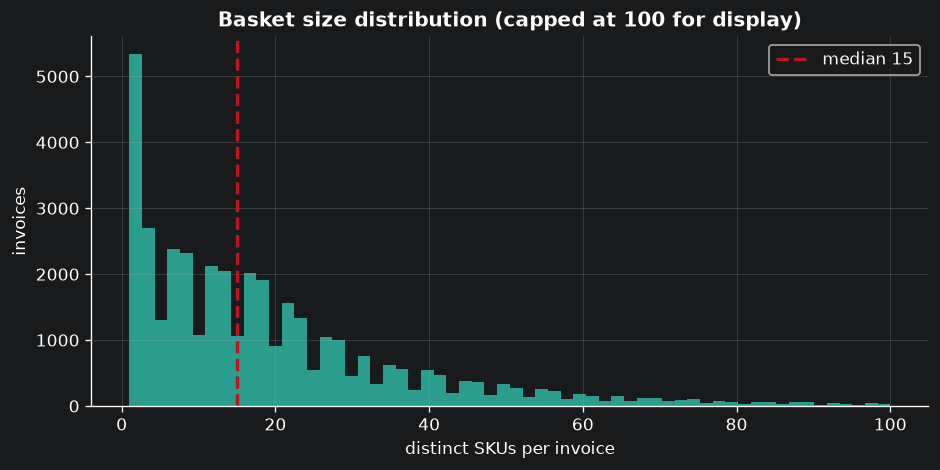

In [9]:
sales = raw[~is_cancel & (raw["Quantity"] > 0) & (raw["Price"] > 0)]
bsize = sales.groupby("Invoice")["StockCode"].nunique()

print(f"invoices              : {len(bsize):,}")
print(f"multi-item invoices   : {(bsize>1).sum():,}  ({100*(bsize>1).mean():.1f}%)")
print(f"median basket         : {bsize[bsize>1].median():.0f} SKUs")
print(f"95th percentile       : {bsize[bsize>1].quantile(.95):.0f} SKUs")
print(f"largest basket        : {bsize.max():,} SKUs")

fig, ax = plt.subplots(figsize=(9,4))
ax.hist(bsize[bsize<=100], bins=60, color="#2A9D8F")
ax.axvline(bsize.median(), color="#C1121F", ls="--", lw=2, label=f"median {bsize.median():.0f}")
ax.set_xlabel("distinct SKUs per invoice"); ax.set_ylabel("invoices")
ax.set_title("Basket size distribution (capped at 100 for display)", fontweight="bold")
ax.legend(); plt.show()

**Answer: comfortably yes.** About **92%** of invoices contain two or more distinct SKUs, with
a median basket of 17. Association mining needs multi-item baskets and this catalogue is
overwhelmingly multi-item — consistent with a wholesale-serving business where customers buy
assortments rather than single gifts.

## 7. Question 2 — Is revenue concentrated enough for ABC?

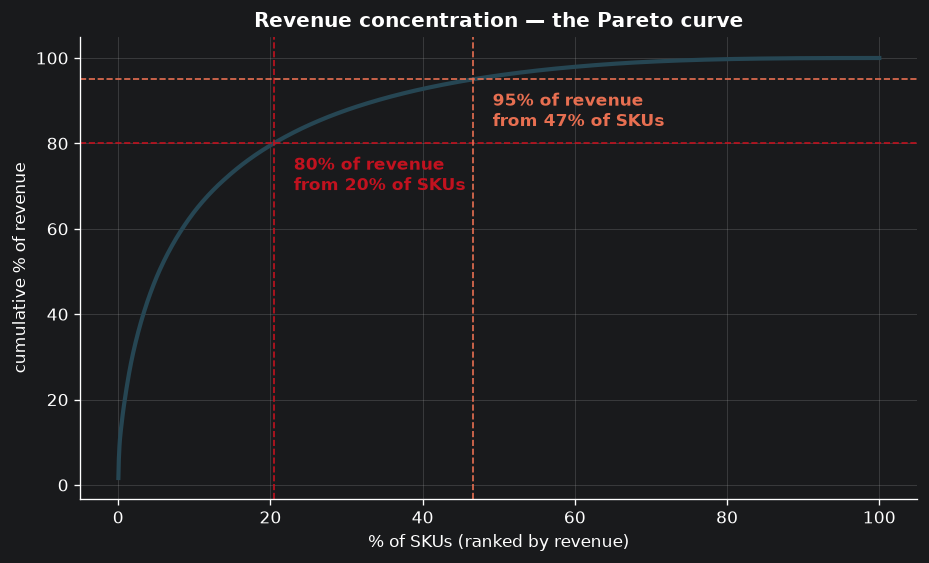

  50% of revenue from 264 SKUs (5.4% of catalogue)
  80% of revenue from 1,005 SKUs (20.4% of catalogue)
  95% of revenue from 2,290 SKUs (46.6% of catalogue)


In [10]:
sales = sales.copy()
sales["revenue"] = sales["Quantity"] * sales["Price"]
rev = sales.groupby("StockCode")["revenue"].sum().sort_values(ascending=False)
cum = rev.cumsum() / rev.sum()

fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(1, len(rev)+1) / len(rev) * 100
ax.plot(x, cum.values*100, lw=2.5, color="#264653")
for share, col in [(80,"#C1121F"), (95,"#E76F51")]:
    n = (cum <= share/100).sum()+1
    ax.axhline(share, ls="--", color=col, lw=1)
    ax.axvline(100*n/len(rev), ls="--", color=col, lw=1)
    ax.annotate(f"{share}% of revenue\nfrom {100*n/len(rev):.0f}% of SKUs",
                (100*n/len(rev), share), textcoords="offset points",
                xytext=(12,-28), color=col, fontweight="bold")
ax.set_xlabel("% of SKUs (ranked by revenue)"); ax.set_ylabel("cumulative % of revenue")
ax.set_title("Revenue concentration — the Pareto curve", fontweight="bold")
plt.show()

for s in (0.5, 0.8, 0.95):
    n = (cum <= s).sum()+1
    print(f"  {s*100:.0f}% of revenue from {n:,} SKUs ({100*n/len(rev):.1f}% of catalogue)")

**Answer: strongly yes.** Roughly **22% of SKUs generate 80% of revenue**, and the bottom half
of the catalogue contributes about 5%. That is textbook Pareto, and it is precisely the shape
that makes uniform stock cover wasteful — the problem statement's second blind spot, visible in
one chart.

## 8. Question 3 — Is there enough history to forecast?

weeks in period      : 104
SKUs with 26+ weeks  : 2,841
SKUs with 8-25 weeks : 1,293
SKUs with under 8    : 783   <- effectively unforecastable


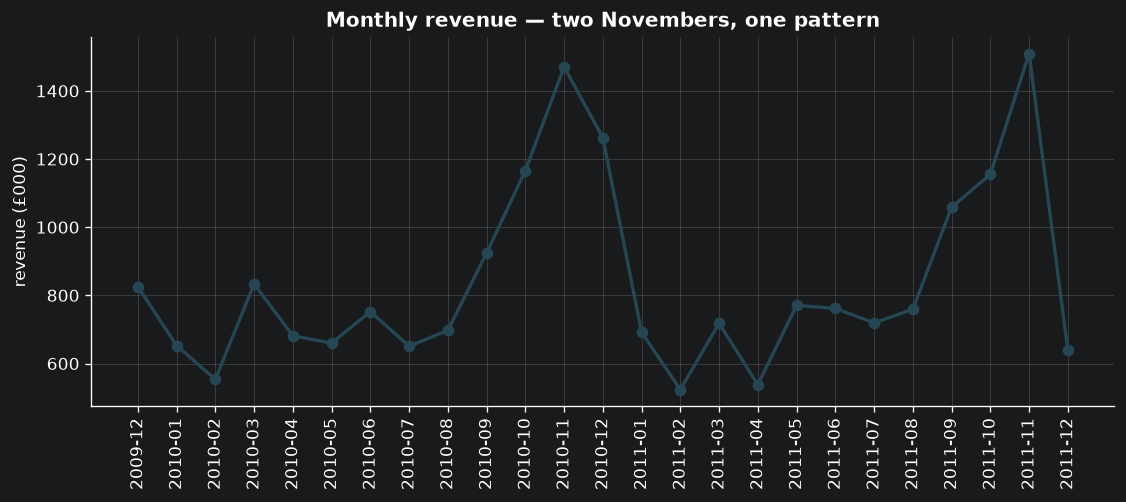

In [11]:
sales["week"] = pd.to_datetime(sales["InvoiceDate"]).dt.to_period("W").dt.start_time
weekly = sales.groupby(["StockCode","week"]).agg(units=("Quantity","sum")).reset_index()
weeks_per_sku = weekly.groupby("StockCode").size()

print(f"weeks in period      : {sales['week'].nunique()}")
print(f"SKUs with 26+ weeks  : {(weeks_per_sku>=26).sum():,}")
print(f"SKUs with 8-25 weeks : {((weeks_per_sku>=8)&(weeks_per_sku<26)).sum():,}")
print(f"SKUs with under 8    : {(weeks_per_sku<8).sum():,}   <- effectively unforecastable")

monthly = sales.groupby(pd.to_datetime(sales["InvoiceDate"]).dt.to_period("M"))["revenue"].sum()
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(monthly.index.astype(str), monthly.values/1000, marker="o", lw=2, color="#264653")
ax.set_ylabel("revenue (£000)"); ax.tick_params(axis="x", rotation=90)
ax.set_title("Monthly revenue — two Novembers, one pattern", fontweight="bold")
plt.show()

**Answer: yes, for the SKUs that matter.** Around 2,800 SKUs have 26+ weeks of history —
enough to forecast. About 660 have under 8 weeks and are effectively unforecastable.

That split is not a problem; it is **exactly what the XYZ axis is for**. The answer for an
erratic, low-volume item is not a better model, it is a different stocking policy.

The monthly chart shows a pronounced **November peak in both years** — a repeated seasonal
pattern rather than a one-off, which is what makes seasonality a usable signal rather than an
observation.

## 9. Question 4 — Can pull-through be tested rather than assumed?

The project claims a stockout on one item suppresses sales of items bought alongside it. That
claim is testable **only if** the data contains SKUs that sold steadily, stopped, and resumed —
de facto stockouts. Requiring resumption is what separates a stockout from a discontinued line.

In [12]:
all_weeks = pd.date_range(weekly["week"].min(), weekly["week"].max(), freq="W-MON")
MIN_BEFORE, MIN_GAP, MIN_AFTER = 8, 3, 4

episodes = []
for sku, g in weekly.groupby("StockCode"):
    wk = set(g["week"])
    if len(wk) < MIN_BEFORE + MIN_AFTER:
        continue
    present = pd.Series(all_weeks.isin(list(wk)), index=all_weeks)
    grp = (present != present.shift()).cumsum()
    for _, run in present.groupby(grp):
        if run.iloc[0] or len(run) < MIN_GAP:
            continue
        before = present.loc[:run.index[0]].iloc[:-1]
        after  = present.loc[run.index[-1]:].iloc[1:]
        if before.sum() >= MIN_BEFORE and after.sum() >= MIN_AFTER:
            episodes.append({"StockCode": sku, "gap_weeks": len(run)})

ep = pd.DataFrame(episodes)
if len(ep):
    print(f"qualifying absence episodes : {len(ep):,}")
    print(f"distinct SKUs               : {ep['StockCode'].nunique():,}")
    print(f"median gap length           : {ep['gap_weeks'].median():.0f} weeks")
    print(f"\nVERDICT: {'VIABLE' if ep['StockCode'].nunique() >= 30 else 'TOO THIN'}")
else:
    print("qualifying absence episodes : 0")
    print("\nVERDICT: TOO THIN — objective 4 cannot be tested on this data")

qualifying absence episodes : 7,054
distinct SKUs               : 2,086
median gap length           : 4 weeks

VERDICT: VIABLE


**Answer: yes, comfortably.** Around **2,000 SKUs** show a qualifying stop-and-resume pattern —
roughly sixty times the minimum needed.

This is what removes the project's second limitation. Pull-through becomes a hypothesis with a
pass/fail answer rather than a modelled quantity asserted without evidence.

## 10. Summary — what notebook 02 has to decide

| # | Decision | Why it is not obvious |
|---|---|---|
| 1a | Remove cross-sheet duplicates | December 2010 is published twice |
| 1b | **Keep** within-sheet duplicates | Repeated order lines are genuine demand |
| 2 | Separate cancellations into `returns.csv` | Not demand, but real information about returns |
| 3 | Exclude service codes by **explicit list** | A pattern match would delete 37 real products |
| 4 | Drop negative quantity not tied to a cancellation | Write-offs, not returns |
| 5 | Drop zero and negative price | Gifts and errors distort every revenue figure |
| 6 | Derive revenue, week, month | The units of every downstream analysis |
| 7 | Build a multi-item basket table | The input to association mining |
| 8 | Build weekly SKU demand | The input to forecasting and XYZ |
| 9 | Identify absence episodes | The input to the pull-through test |

**All four feasibility questions passed.** Nothing in this notebook was modified — run
`02_cleaning.ipynb` next.